# Create base demand

This notebook processes a collection of load curves obtained from Svenska Kraftnät (currently the last 10 years 2014-2023 for which whole year data is available) and creates a base demand load curve for each concession area (SE1-SE4).

**2024-11-13**

- This version of the base demand is a rough alpha version.
- Currently the base demand is calculated as the average per hour of the 5 years 2019-2023.
- The extra day in the leap year 2020 is discarded. 
- Time series are not aligned which means that the weekday/weekend pattern is reduced.

In [1]:
# Import libraries

import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from io import StringIO
import json

root_path = Path(globals()['_dh'][0]).resolve().parent.parent.parent
sys.path.append(str(root_path))

from paths import input_path
from generator.library.utilities import get_path, sort_params

In [2]:
# Load the configuration

with (Path('config-country.json')).open('r', encoding='utf-8') as file:
    config = json.load(file)


In [3]:
config

{'name': 'base_demand/base_load_curve',
 'access': 'public',
 'admin-level': 'country',
 'properties': {'base-year': 2025,
  'geography': 'SE',
  'normalized': False,
  'resolution': '1h',
  'aggregation': 'mean'}}

In [4]:
# Read the files and build a data frame of 10 years data

lc_list = []

for year in range(2014,2024):
    lc = pd.read_excel(f"timvarden-{year}-01-12.xls", usecols=[0,1,2,3,4], skiprows=[0,1,2,3], names=['timestamp', 'SE1','SE2','SE3','SE4'])
    lc_list.append(lc)

load_curves = pd.concat(lc_list)

load_curves['timestamp'] = pd.to_datetime(load_curves['timestamp'], errors='coerce') # Parse timestamp as datetime (the date format is inconsistent between files)
load_curves.set_index('timestamp', inplace=True) # Use timestamp as indes
load_curves = -load_curves # Make load into demand by flipping the sign
load_curves = load_curves.sort_index() # Sort on date


In [5]:
# Read in energy projections from Energimyndigheten

url = 'http://pxexternal.energimyndigheten.se/api/v1/sv/Energimyndighetens_statistikdatabas/Prognoser/EN_Prognos_6a.px'
query = {
  "query": [],
  "response": {
    "format": "csv"
  }
}

##  Make the request (POST)
response = requests.post(url, json=query)
if response.status_code == 200:
    csv_data = StringIO(response.text)
    response_csv = pd.read_csv(csv_data)
else:
    print(f"Error: {response.status_code}")


total_electricity_demand = response_csv[response_csv['Sektor'] == 'Totalt'].rename(columns={'År': 'Year'}).set_index('Year').drop(columns=['Sektor']).rename(columns={'Prognos elanvändning, TWh': 'Demand'})

total_electricity_demand


KeyError: "None of ['Year'] are in the columns"

In [ ]:
# Normalize load curves to sum up to 1 each year
norm_load_curves = load_curves.copy()

for col in norm_load_curves.columns:
    norm_load_curves[col] = load_curves[col].div(load_curves.groupby(load_curves.index.year)[col].transform('sum'))

In [6]:
# Calculate normalized base demand load curve as the average of the last 5 years

five_year_norm_load_curves = norm_load_curves[(norm_load_curves.index >= '2019-01-01') & ~(norm_load_curves.index.strftime('%m-%d') == '02-29')]

normalized_base_load_curve = five_year_norm_load_curves.groupby([five_year_norm_load_curves.index.month, five_year_norm_load_curves.index.day, five_year_norm_load_curves.index.hour]).mean()

normalized_base_load_curve.index.names = ['month', 'day', 'hour']
normalized_base_load_curve = normalized_base_load_curve.reset_index()

normalized_base_load_curve['timestamp'] = pd.to_datetime(
    f"{biddingzone_config['base-year']}-" + normalized_base_load_curve['month'].astype(str) + '-' + normalized_base_load_curve['day'].astype(str) + ' ' + normalized_base_load_curve['hour'].astype(str) + ':00:00'
)

normalized_base_load_curve.set_index('timestamp', inplace=True)
normalized_base_load_curve = normalized_base_load_curve.drop(columns=['month', 'day', 'hour'])

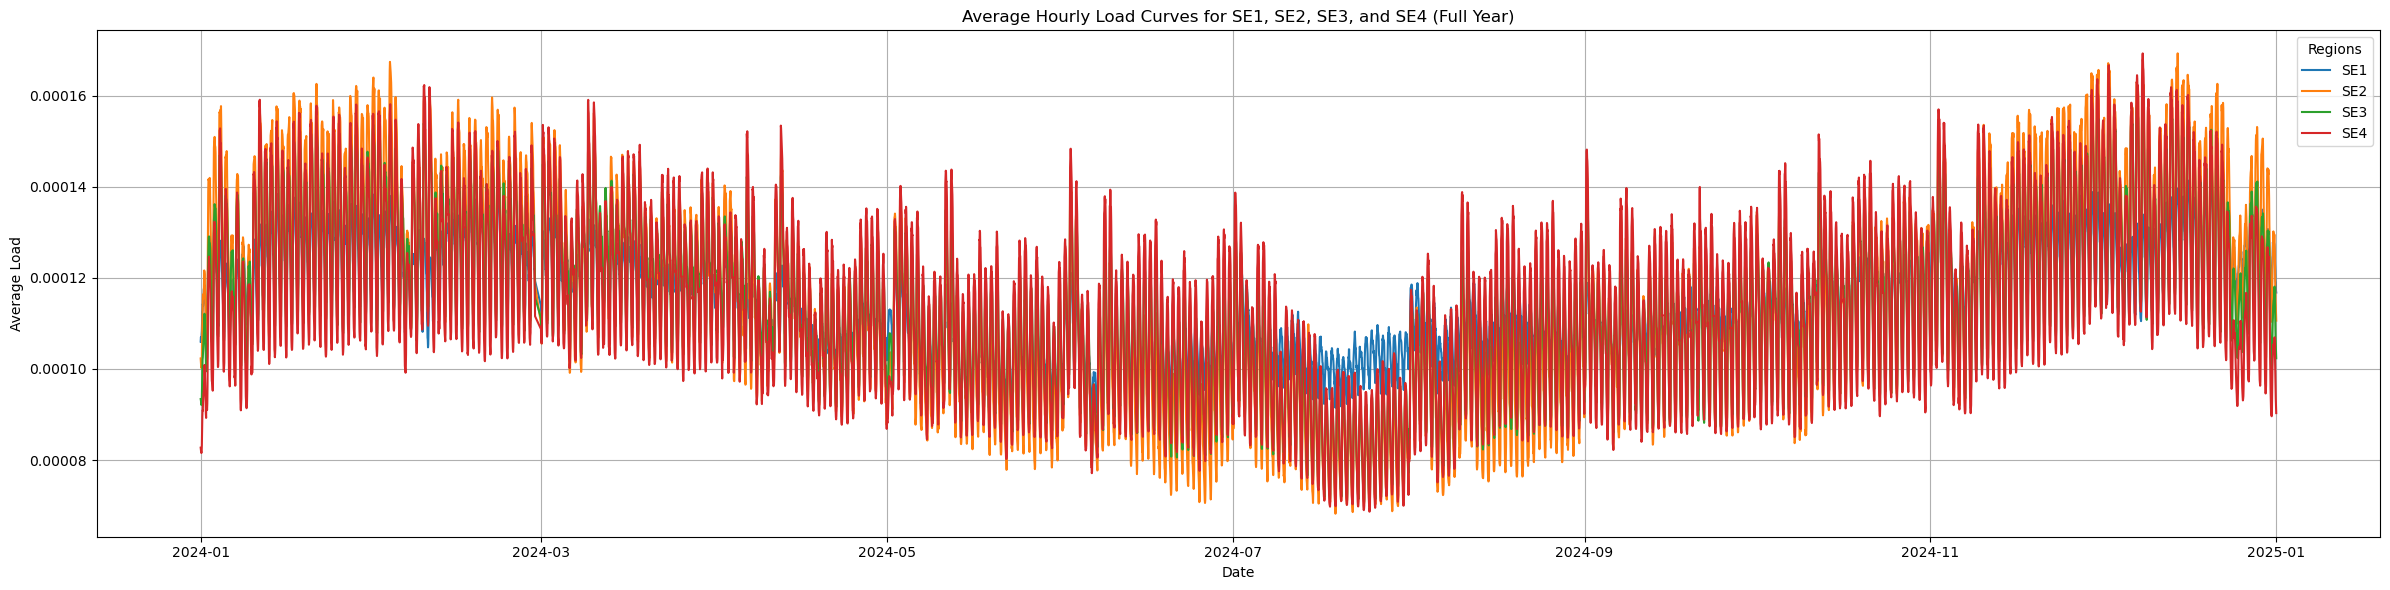

In [7]:
# Plotting the average_yearly DataFrame
plt.figure(figsize=(24, 6))

for column in normalized_base_load_curve.columns:
    plt.plot(normalized_base_load_curve.index, normalized_base_load_curve[column], label=column)

# Adding labels, title, and legend
plt.title("Average Hourly Load Curves for SE1, SE2, SE3, and SE4 (Full Year)")
plt.xlabel("Date")
plt.ylabel("Average Load")
plt.legend(title="Regions")
plt.grid(visible=True)
plt.tight_layout()

plt.show()

In [8]:
national_base_load_curve = normalized_base_load_curve.sum(axis=1).to_frame(name='Sweden') / 4 * total_electricity_demand.loc[2025, 'Demand'] * 1_000_000

In [ ]:
# Write base load curves to file
 
# base_load_curve.to_csv(input_path / biddingzone_config['access'] / 'base_demand' / get_path("base_load_curve",biddingzone_config,"csv"))
national_base_load_curve.to_csv(input_path / config['access'] / f"{config['name']},{sort_params(config['properties'])}.csv")